# **Regression :**
**Regression finds the best-fit line or curve that predicts the output y from one or more input variables x.**

## **Multiple- Linear Regression :**
**Formula :** y = m1 x1 + m2 x2 +...+ c
* A method to find the best-fit linear equation using more than one independent variable.
* In multiple linear regression, the predictions change in a predictable weighted way because multiple inputs x1,x2,… follow linear patterns, so the model fits a flat hyperplane (n no.of Dimensions) in higher dimensions. The range of y varies steadily according to all the inputs.


In [ ]:
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# **Importing Data**

In [ ]:
data=pd.read_csv('/content/Housing.csv')
df=pd.DataFrame(data)
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


# **EDA**

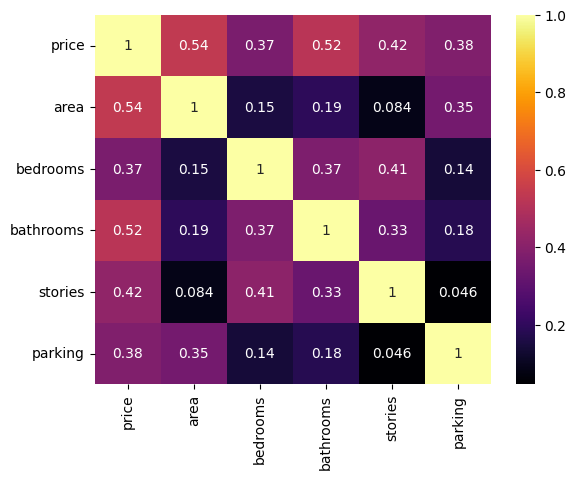

In [ ]:

sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='inferno') #annot=True means show values
plt.show()

# **Encoding**

In [ ]:
# return categorical column
df.select_dtypes(include='object').columns

Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [ ]:
# Encoing Method using sirs code
column=['guestroom']
for c in column:
  df[c]=df[c].astype(str).str.strip().str.lower()
df['guestroom']=df['guestroom'].map({'yes':1,'no':0})
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,0,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,0,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,0,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,0,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,1,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,0,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,0,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,0,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,0,no,no,no,0,no,furnished


In [ ]:
# Encoding using replace
col = ['mainroad','guestroom','basement','hotwaterheating',
               'airconditioning','prefarea','furnishingstatus']

df[col] = df[col].replace({'yes': 1, 'no': 0})
df

/tmp/ipython-input-4031807516.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace({'yes': 1, 'no': 0})


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,furnished
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,furnished
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,semi-furnished
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,furnished
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,1,0,1,0,0,2,0,unfurnished
541,1767150,2400,3,1,1,0,0,0,0,0,0,0,semi-furnished
542,1750000,3620,2,1,1,1,0,0,0,0,0,0,unfurnished
543,1750000,2910,3,1,1,0,0,0,0,0,0,0,furnished


In [ ]:
df=pd.get_dummies(df,columns=['furnishingstatus'],drop_first=True)
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,False,False
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,False,False
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,True,False
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,False,False
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,1,0,1,0,0,2,0,False,True
541,1767150,2400,3,1,1,0,0,0,0,0,0,0,True,False
542,1750000,3620,2,1,1,1,0,0,0,0,0,0,False,True
543,1750000,2910,3,1,1,0,0,0,0,0,0,0,False,False


# **Dividing Data for Training & Testing**

In [ ]:
x = df.drop('price',axis=1)
y = df['price']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)

# **Scaling / Standardizing Data to sent to ML**

In [ ]:
scaler = StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.fit_transform(x_test)
x_train_scaled
x_test_scaled

array([[ 0.32427925,  1.44943654,  1.18232428, ..., -0.54916965,
        -0.8       ,  1.31656118],
       [ 0.60301958,  0.02603778,  1.18232428, ...,  1.82093094,
        -0.8       , -0.75955453],
       [-0.53981577, -1.39736098, -0.61305703, ..., -0.54916965,
         1.25      , -0.75955453],
       ...,
       [-0.3679259 ,  1.44943654,  2.97770559, ..., -0.54916965,
         1.25      , -0.75955453],
       [ 1.76443762,  0.02603778, -0.61305703, ..., -0.54916965,
         1.25      , -0.75955453],
       [-0.72099699,  0.02603778,  1.18232428, ..., -0.54916965,
         1.25      , -0.75955453]])

# **Making data learn and follow Linear Regression Algorithm**

In [ ]:
lr=LinearRegression()
lr.fit(x_train_scaled,y_train)
# we are telling it to learn from the data

LinearRegression()

# **Our Prediction**

In [ ]:
y_pred=lr.predict(x_test_scaled)  # it will predict the answer for y_test which is actual and this y_pred is prediction of y_test
y_pred

array([5187371.60026388, 6862227.89372732, 3049788.7185256 ,
       4482329.78432354, 3239269.0830245 , 3569938.68038108,
       5650834.65525961, 6248822.84550601, 2774685.32363731,
       2527133.37296173, 9272757.62385375, 2770533.4875908 ,
       3015791.21343651, 3409483.0628785 , 3769697.52199238,
       4993107.43607413, 2938411.89031395, 4763591.68130848,
       4528255.1410773 , 3551286.60312991, 5569109.28651245,
       5838049.15535984, 2697611.60130905, 4810282.36289636,
       5538935.30399421, 7571648.39890398, 3341321.28027133,
       5140472.33398035, 8264294.73333847, 3317666.05277781,
       6181384.69183366, 3336939.51052025, 6515618.09483412,
       4205796.48664571, 3569430.91869941, 5607017.90067269,
       5043792.80000011, 4343882.26158853, 3040945.08030197,
       4385795.66749093, 4699521.65597609, 3382507.46216468,
       6841758.5923149 , 3988796.38095987, 3743186.30387136,
       4237014.93162031, 6508882.35510722, 4064551.41502231,
       3823679.04525986,

In [ ]:
#Error=Actual-prediction
print("MAE:",mean_absolute_error(y_test,y_pred))
print("R2_score:",r2_score(y_test,y_pred))

MAE: 901025.980426326
R2_score: 0.650738529720958


# **Checking Predicted Price**

In [ ]:
x_train.columns

Index(['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom',
       'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea',
       'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished'],
      dtype='object')

In [ ]:
# We are passing columns values to check what will be the price prediction of that columns
new_house=pd.DataFrame({'area':[1200], 'bedrooms':[3], 'bathrooms':[3], 'stories':[2], 'mainroad':[1], 'guestroom':[1],
       'basement':[1], 'hotwaterheating':[1], 'airconditioning':[0], 'parking':[0], 'prefarea':[1],
       'furnishingstatus_semi-furnished':[0], 'furnishingstatus_unfurnished':[0]})
new_house

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,1200,3,3,2,1,1,1,1,0,0,1,0,0


In [ ]:
# Reorder column sequence
# if data columns are jumbled then use this to reorder it acoording to the data columns of x
new_df=new_house[x.columns]
new_df

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,1200,3,3,2,1,1,1,1,0,0,1,0,0


In [ ]:
# now standardize the data to get the prediction of price
new_house_scaled=scaler.transform(new_df)
new_house_scaled

array([[-1.85918667,  0.02603778,  2.97770559,  0.16014368,  0.42409446,
         2.30384294,  1.42724806,  5.63914887, -0.67180908, -0.82133347,
         1.82093094, -0.8       , -0.75955453]])

In [ ]:
pred_price=lr.predict(new_house_scaled)
pred_price

array([6941590.12162602])